# Practical 05 — Decision Tree (ID3) and Performance Analysis

**Laboratory:** M.Tech Machine Learning  
**Kernel:** `ml-lab-kernel`  
**Syllabus:** *Implement Decision Tree (ID3) on a dataset and analyse performance.*  
**Data:** Quinlan *Play Tennis* (14 rows, categorical ID3) + Wisconsin Breast Cancer (sklearn).

### Lab map

```text
[1] Colab header  →  [2] DATASET CONFIG
        ↓
[3] Play Tennis hand table  H(S)=0.940 → IG(Outlook) wins the root
        ↓
[4] Recursive ID3 from scratch + ASCII tree
        ↓
[5] sklearn entropy tree on Breast Cancer (split, depth search)
        ↓
[6] plot_tree, accuracy vs depth, confusion matrix + ROC  →  [7] Viva
```

### Learning outcomes

1. Compute **Shannon entropy** $H(S)$ and **information gain** $\mathrm{IG}(S,A)$ by hand on Play Tennis.
2. Prove **Outlook** is the ID3 root (highest IG).
3. Grow a **pure-Python ID3** tree and print it in ASCII.
4. Fit `DecisionTreeClassifier(criterion='entropy')` with a search over `max_depth` and `min_samples_split`.
5. Read **overfitting** from train vs test accuracy vs depth, plus a **confusion matrix** and **ROC–AUC**.

> **Why this matters:** a tree is not “magic if-then rules.” It is **greedy entropy reduction**. If you cannot show why Outlook splits first, you cannot defend ID3 in a viva.


## Colab 1-click header (skip upload on a campus PC)

**Google Colab**

1. Runtime → Run all (or this cell, then **DATASET CONFIG**).
2. Own CSV: **upload** when prompted, or set `COLAB_DRIVE_CSV`.
3. No files: Play Tennis uses an in-notebook table; cancer uses `load_breast_cancer`.

**Local Jupyter (`ml-lab-kernel`)** — this cell only reports the runtime.


In [1]:
# --- Colab / local compatibility (safe to run everywhere) ---
from __future__ import annotations

import sys
from pathlib import Path

from IPython.display import HTML, display

IN_COLAB = "google.colab" in sys.modules


def _banner(text: str, bg: str = "#14532d") -> None:
    display(
        HTML(
            f'<div style="background:{bg};color:#fff;padding:10px 14px;'
            f"border-radius:8px;font-family:Segoe UI,sans-serif;"
            f'font-weight:600;margin:6px 0;">{text}</div>'
        )
    )


def _why(text: str) -> None:
    display(
        HTML(
            f'<div style="background:#ecfdf5;border-left:4px solid #047857;'
            f"padding:10px 14px;border-radius:4px;font-family:Segoe UI,sans-serif;"
            f'margin:8px 0;"><b>Why this matters.</b> {text}</div>'
        )
    )


def _rule(title: str = "") -> None:
    bar = "=" * 72
    print(f"\n{bar}\n {title}\n{bar}" if title else bar)


_banner("0 · Runtime")
print(f"Colab detected: {IN_COLAB}  |  Python {sys.version.split()[0]}")

if IN_COLAB:
    get_ipython().run_line_magic(
        "pip", "install -q numpy pandas matplotlib seaborn scikit-learn"
    )  # why: Colab VMs start empty; campus PCs already have the lab venv
    print("Colab: packages checked via %pip.")
else:
    print("Local kernel: skipping %pip. Use ml-lab-kernel / the lab venv.")


def colab_upload_to(dest: Path) -> Path | None:
    if not IN_COLAB:
        return None
    from google.colab import files  # type: ignore

    uploaded = files.upload()  # why: Colab has no ./data until you add one
    if not uploaded:
        return None
    name, blob = next(iter(uploaded.items()))
    dest = dest if dest.suffix else dest / name
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_bytes(blob)
    print(f"Saved upload -> {dest}")
    return dest


def colab_mount_drive() -> Path | None:
    if not IN_COLAB:
        return None
    from google.colab import drive  # type: ignore

    drive.mount("/content/drive")  # why: reuse a CSV already in Drive
    root = Path("/content/drive/MyDrive")
    return root if root.exists() else None


Colab detected: False  |  Python 3.14.0
Local kernel: skipping %pip. Use ml-lab-kernel / the lab venv.


## DATASET CONFIG BLOCK — the only cell most beginners edit

```text
  DATA_PATH ──────────► Breast Cancer CSV (sklearn benchmark)
  FEATURE_COLUMNS ────► numeric predictors (None = all numeric except the target)
  TARGET_COLUMN ──────► diagnosis (malignant / benign)
  DROP_COLUMNS ───────► IDs to ignore
  PLAY_TENNIS_PATH ───► 14-row categorical table for the ID3 hand calculation
```

> **Why this matters:** ID3 on Tennis is a **discrete** walkthrough. The cancer tree is **numeric CART-style binary cuts** with entropy impurity. Mixing the two files in the wrong slot breaks both stories.


In [2]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  DATASET CONFIG — swap CSVs / features / target here                 ║
# ╚══════════════════════════════════════════════════════════════════════╝

DATA_PATH = "data/breast_cancer.csv"     # why: sklearn-style numeric benchmark
TARGET_COLUMN = "diagnosis"              # why: malignant vs benign
FEATURE_COLUMNS = None                   # None = every numeric column except the target
DROP_COLUMNS: list[str] = []             # why: drop IDs/names before fitting

PLAY_TENNIS_PATH = "data/play_tennis.csv"  # why: Quinlan 14-row ID3 worked example
TENNIS_TARGET = "play"

# Colab-only (ignored locally)
COLAB_DRIVE_CSV = None
COLAB_OFFER_UPLOAD = True

from pathlib import Path as _Path

_rule("DATASET CONFIG")
print(f"DATA_PATH          = {DATA_PATH}")
print(f"TARGET_COLUMN      = {TARGET_COLUMN}")
print(f"FEATURE_COLUMNS    = {FEATURE_COLUMNS}")
print(f"DROP_COLUMNS       = {DROP_COLUMNS}")
print(f"PLAY_TENNIS_PATH   = {PLAY_TENNIS_PATH}")
print(f"cancer CSV exists: {_Path(DATA_PATH).is_file()}")
print(f"tennis CSV exists: {_Path(PLAY_TENNIS_PATH).is_file()}")



 DATASET CONFIG
DATA_PATH          = data/breast_cancer.csv
TARGET_COLUMN      = diagnosis
FEATURE_COLUMNS    = None
DROP_COLUMNS       = []
PLAY_TENNIS_PATH   = data/play_tennis.csv
cancer CSV exists: True
tennis CSV exists: True


## 0. Environment, seed, and large high-DPI figures

In [3]:
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

SEED = 42  # why: tree splits and the train/test shuffle must be repeatable
np.random.seed(SEED)

plt.rcParams.update(
    {
        "figure.figsize": (14, 7),
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "font.size": 13,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 13,
        "figure.titlesize": 18,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)
pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 1000)
sns.set_theme(style="whitegrid", palette="colorblind")

_banner("0 · Libraries")
print("Python", sys.version.split()[0])
print("numpy", np.__version__, "| sklearn DecisionTreeClassifier")
print("SEED =", SEED)


Python 3.14.0
numpy 2.5.2 | sklearn DecisionTreeClassifier
SEED = 42


## 1. Load Play Tennis and Breast Cancer

| Priority | Tennis | Cancer |
|----------|--------|--------|
| 1 | `PLAY_TENNIS_PATH` | `DATA_PATH` |
| 2 | in-notebook 14-row table | `load_breast_cancer` |


In [4]:
TENNIS_FALLBACK = pd.DataFrame(
    {
        "outlook": [
            "sunny", "sunny", "overcast", "rain", "rain", "rain", "overcast",
            "sunny", "sunny", "rain", "sunny", "overcast", "overcast", "rain",
        ],
        "temperature": [
            "hot", "hot", "hot", "mild", "cool", "cool", "cool",
            "mild", "cool", "mild", "mild", "mild", "hot", "mild",
        ],
        "humidity": [
            "high", "high", "high", "high", "normal", "normal", "normal",
            "high", "normal", "normal", "normal", "high", "normal", "high",
        ],
        "wind": [
            "weak", "strong", "weak", "weak", "weak", "strong", "strong",
            "weak", "weak", "weak", "strong", "strong", "weak", "strong",
        ],
        "play": [
            "no", "no", "yes", "yes", "yes", "no", "yes",
            "no", "yes", "yes", "yes", "yes", "yes", "no",
        ],
    }
)


def load_tennis() -> tuple[pd.DataFrame, str]:
    p = Path(PLAY_TENNIS_PATH)
    if p.is_file():
        df_t = pd.read_csv(p)  # why: version-controlled 14-row lab table
        df_t.columns = [c.strip().lower() for c in df_t.columns]
        return df_t, "local"
    return TENNIS_FALLBACK.copy(), "inline"


def load_cancer() -> tuple[pd.DataFrame, str]:
    p = Path(DATA_PATH)
    if IN_COLAB and COLAB_DRIVE_CSV:
        colab_mount_drive()
        drive_p = Path(COLAB_DRIVE_CSV)
        if drive_p.is_file():
            return pd.read_csv(drive_p), "gdrive"
    if IN_COLAB and COLAB_OFFER_UPLOAD and not p.is_file():
        saved = colab_upload_to(p)
        if saved is not None:
            return pd.read_csv(saved), "colab_upload"
    if p.is_file():
        return pd.read_csv(p), "local"
    bunch = load_breast_cancer(as_frame=True)  # why: last-resort numeric table
    frame = bunch.frame.copy()
    frame = frame.rename(columns={"target": TARGET_COLUMN})
    frame[TARGET_COLUMN] = frame[TARGET_COLUMN].map({0: "malignant", 1: "benign"})
    return frame, "sklearn"


tennis, tennis_origin = load_tennis()
cancer, cancer_origin = load_cancer()

for col in DROP_COLUMNS:
    if col in cancer.columns:
        cancer = cancer.drop(columns=[col])

if TARGET_COLUMN not in cancer.columns:
    raise KeyError(f"TARGET_COLUMN={TARGET_COLUMN!r} not in {list(cancer.columns)}")

if FEATURE_COLUMNS is None:
    feature_cols = [
        c
        for c in cancer.select_dtypes(include=[np.number]).columns
        if c != TARGET_COLUMN
    ]
else:
    missing = [c for c in FEATURE_COLUMNS if c not in cancer.columns]
    if missing:
        raise KeyError(f"FEATURE_COLUMNS missing: {missing}")
    feature_cols = list(FEATURE_COLUMNS)

_banner("1 · Loaded tables")
print(f"Tennis origin = {tennis_origin} | shape = {tennis.shape}")
print(f"Cancer origin = {cancer_origin} | shape = {cancer.shape} | n_features = {len(feature_cols)}")
display(tennis.style.set_caption("Play Tennis (all 14 rows) — ID3 worked example"))


Tennis origin = local | shape = (14, 5)
Cancer origin = local | shape = (569, 31) | n_features = 30


,outlook,temperature,humidity,wind,play
0,sunny,hot,high,weak,no
1,sunny,hot,high,strong,no
2,overcast,hot,high,weak,yes
3,rain,mild,high,weak,yes
4,rain,cool,normal,weak,yes
5,rain,cool,normal,strong,no
6,overcast,cool,normal,strong,yes
7,sunny,mild,high,weak,no
8,sunny,cool,normal,weak,yes
9,rain,mild,normal,weak,yes


## 2. Hand calculation — Play Tennis root split

**Class counts:** 9 **yes**, 5 **no**, $n=14$.

$$
H(S)=-\sum_k p_k\log_2 p_k
=-\frac{9}{14}\log_2\frac{9}{14}-\frac{5}{14}\log_2\frac{5}{14}
\approx 0.940\ \text{bits}.
$$

**Information gain** of attribute $A$:

$$
\mathrm{IG}(S,A)=H(S)-\sum_{v}\frac{|S_v|}{|S|}\,H(S_v).
$$

ID3 picks $A^\star=\arg\max_A \mathrm{IG}(S,A)$. On this table that is **Outlook**.

> **Why this matters:** you must be able to reproduce $H(S)\approx 0.940$ and the IG ranking with a calculator. The tree is only as trustworthy as this first split.


In [5]:
_banner("2 · Entropy and information gain (Play Tennis)")


def entropy(labels: pd.Series) -> float:
    counts = labels.value_counts()
    p = counts.to_numpy(dtype=np.float64) / counts.sum()  # why: class proportions in this node
    p = p[p > 0]  # why: 0 log 0 is defined as 0 — drop empty classes
    return float(-np.sum(p * np.log2(p)))


def information_gain(frame: pd.DataFrame, attr: str, target: str) -> tuple[float, pd.DataFrame]:
    h_s = entropy(frame[target])
    n = len(frame)
    rows = []
    remainder = 0.0
    for value, part in frame.groupby(attr, dropna=False):
        h_v = entropy(part[target])
        w = len(part) / n  # why: weighted average of child entropies
        remainder += w * h_v
        vc = part[target].value_counts()
        rows.append(
            {
                "value": value,
                "n": len(part),
                "yes": int(vc.get("yes", 0)),
                "no": int(vc.get("no", 0)),
                "H(S_v)": h_v,
                "weight |Sv|/|S|": w,
            }
        )
    ig = h_s - remainder
    return ig, pd.DataFrame(rows)


h_s = entropy(tennis[TENNIS_TARGET])
_why(
    f"H(S) = {h_s:.6f} bits. Textbook value is 0.940. "
    "A pure node (all yes or all no) would have H = 0."
)
assert abs(h_s - 0.940) < 5e-3  # why: 0.940 is the 3-decimal lab-manual figure

attrs = [c for c in tennis.columns if c != TENNIS_TARGET]
ig_rows = []
child_tables = {}
for a in attrs:
    ig, kids = information_gain(tennis, a, TENNIS_TARGET)
    ig_rows.append({"attribute": a, "IG(S, A)": ig})
    child_tables[a] = kids

ig_tbl = pd.DataFrame(ig_rows).sort_values("IG(S, A)", ascending=False)
display(pd.DataFrame({"quantity": ["n", "yes", "no", "H(S) bits"], "value": [14, 9, 5, h_s]}).style.format({"value": "{:.6f}"}).set_caption("Root node"))

for a in attrs:
    display(
        child_tables[a].style.format(precision=4).set_caption(f"Children if we split on {a}")
    )

display(
    ig_tbl.style.format({"IG(S, A)": "{:.6f}"})
    .background_gradient(subset=["IG(S, A)"], cmap="Greens")
    .set_caption("Information gain at the root — Outlook must win")
)

best = ig_tbl.iloc[0]["attribute"]
print(f"ID3 root attribute = {best}  (IG = {ig_tbl.iloc[0]['IG(S, A)']:.6f})")
assert best == "outlook"  # why: classic Quinlan result
print("Verified: Outlook is the unique IG maximiser at the root.")


,quantity,value
0,n,14.000000
1,yes,9.000000
2,no,5.000000
3,H(S) bits,0.940286


,value,n,yes,no,H(S_v),weight |Sv|/|S|
0,overcast,4,4,0,-0.0000,0.2857
1,rain,5,3,2,0.9710,0.3571
2,sunny,5,2,3,0.9710,0.3571


,value,n,yes,no,H(S_v),weight |Sv|/|S|
0,cool,4,3,1,0.8113,0.2857
1,hot,4,2,2,1.0000,0.2857
2,mild,6,4,2,0.9183,0.4286


,value,n,yes,no,H(S_v),weight |Sv|/|S|
0,high,7,3,4,0.9852,0.5000
1,normal,7,6,1,0.5917,0.5000


,value,n,yes,no,H(S_v),weight |Sv|/|S|
0,strong,6,3,3,1.0000,0.4286
1,weak,8,6,2,0.8113,0.5714


,attribute,"IG(S, A)"
0,outlook,0.246750
2,humidity,0.151836
3,wind,0.048127
1,temperature,0.029223


ID3 root attribute = outlook  (IG = 0.246750)
Verified: Outlook is the unique IG maximiser at the root.


## 3. Recursive ID3 from scratch (discrete attributes)

**Grow:** at a node, if labels are pure or no attributes remain → **leaf** (majority class). Else split on $\arg\max \mathrm{IG}$, recurse, **do not reuse** the attribute (classic ID3).

**ASCII print:** `outlook=overcast -> yes` is a finished branch (entropy 0).


In [6]:
_banner("3 · ID3 from scratch")


class ID3Node:
    __slots__ = ("leaf", "label", "attribute", "children")

    def __init__(self, leaf: bool, label=None, attribute=None, children=None):
        self.leaf = leaf
        self.label = label
        self.attribute = attribute
        self.children = children or {}


def majority(labels: pd.Series) -> str:
    return str(labels.value_counts().idxmax())  # why: break ties by pandas' first max count


def id3_fit(frame: pd.DataFrame, attrs: list[str], target: str) -> ID3Node:
    y = frame[target]
    if y.nunique() == 1:
        return ID3Node(True, label=str(y.iloc[0]))  # why: pure node — stop
    if not attrs:
        return ID3Node(True, label=majority(y))  # why: no splits left — vote
    gains = {a: information_gain(frame, a, target)[0] for a in attrs}
    best = max(gains, key=gains.get)
    if gains[best] <= 0:
        return ID3Node(True, label=majority(y))  # why: no remaining information
    kids = {}
    rest = [a for a in attrs if a != best]  # why: ID3 does not reuse a discrete attribute
    for value, part in frame.groupby(best, dropna=False):
        if len(part) == 0:
            kids[str(value)] = ID3Node(True, label=majority(y))
        else:
            kids[str(value)] = id3_fit(part, rest, target)
    return ID3Node(False, attribute=best, children=kids)


def ascii_tree(node: ID3Node, indent: str = "") -> str:
    if node.leaf:
        return indent + f"LEAF -> {node.label}\n"
    lines = indent + f"[{node.attribute}]\n"
    items = list(node.children.items())
    for i, (val, child) in enumerate(items):
        branch = "└─" if i == len(items) - 1 else "├─"
        pad = "   " if i == len(items) - 1 else "│  "
        lines += indent + f"{branch} {node.attribute}={val}\n"
        lines += ascii_tree(child, indent + pad)
    return lines


def id3_predict_row(node: ID3Node, row: pd.Series, default: str) -> str:
    while not node.leaf:
        key = str(row[node.attribute])
        if key not in node.children:
            return default  # why: unseen category at test time
        node = node.children[key]
    return str(node.label)


tennis_attrs = [c for c in tennis.columns if c != TENNIS_TARGET]
tree = id3_fit(tennis, tennis_attrs, TENNIS_TARGET)
_why("If Outlook=overcast, every training row is 'yes' — ID3 should emit a leaf immediately on that branch.")
print(ascii_tree(tree))

pred = tennis.apply(lambda r: id3_predict_row(tree, r, majority(tennis[TENNIS_TARGET])), axis=1)
acc = float((pred == tennis[TENNIS_TARGET]).mean())
print(f"Training accuracy of scratch ID3 on Play Tennis = {acc:.3f} (expect 1.000 — small, noiseless table)")


[outlook]
├─ outlook=overcast
│  LEAF -> yes
├─ outlook=rain
│  [wind]
│  ├─ wind=strong
│  │  LEAF -> no
│  └─ wind=weak
│     LEAF -> yes
└─ outlook=sunny
   [humidity]
   ├─ humidity=high
   │  LEAF -> no
   └─ humidity=normal
      LEAF -> yes

Training accuracy of scratch ID3 on Play Tennis = 1.000 (expect 1.000 — small, noiseless table)


## 4. sklearn entropy tree on Breast Cancer (no leakage)

`DecisionTreeClassifier(criterion='entropy')` uses the **same impurity** as ID3, but **binary numeric thresholds** (CART-style), not multiway Outlook splits.

**Search:** `max_depth` $\times$ `min_samples_split` with 5-fold CV on the **training** split only.

> **Why this matters:** an unpruned tree can reach train accuracy $1.0$ and still fail on new patients. Depth is a knob for that trade-off.


In [7]:
_banner("4 · sklearn DecisionTreeClassifier + grid search")

y_raw = cancer[TARGET_COLUMN].astype(str)
# why: malignant = positive class (1) for recall / ROC of the disease
y = (y_raw.str.lower() == "malignant").astype(int).to_numpy()
X = cancer[feature_cols].to_numpy(dtype=np.float64)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,      # why: 25% hold-out — enough positives in both splits
    random_state=SEED,   # why: same split every re-run
    stratify=y,          # why: keep malignant/benign ratio in train and test
    shuffle=True,
)

param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, None],  # why: None = grow until pure / min_samples
    "min_samples_split": [2, 5, 10, 20],    # why: larger values prune bushy splits
}
search = GridSearchCV(
    DecisionTreeClassifier(criterion="entropy", random_state=SEED),  # why: entropy = ID3-style impurity
    param_grid,
    cv=5,                 # why: 5-fold CV on TRAIN only — test stays frozen
    scoring="accuracy",
    n_jobs=1,             # why: reproducible, notebook-friendly
)
search.fit(X_train, y_train)
best = search.best_estimator_
print("best params:", search.best_params_, "| CV acc =", f"{search.best_score_:.4f}")

yhat_tr = best.predict(X_train)
yhat_te = best.predict(X_test)
proba_te = best.predict_proba(X_test)[:, 1]  # why: P(malignant) for the ROC curve

metrics = pd.DataFrame(
    [
        {
            "split": "train",
            "accuracy": accuracy_score(y_train, yhat_tr),
            "precision": precision_score(y_train, yhat_tr, zero_division=0),
            "recall": recall_score(y_train, yhat_tr, zero_division=0),
            "F1": f1_score(y_train, yhat_tr, zero_division=0),
        },
        {
            "split": "test",
            "accuracy": accuracy_score(y_test, yhat_te),
            "precision": precision_score(y_test, yhat_te, zero_division=0),
            "recall": recall_score(y_test, yhat_te, zero_division=0),
            "F1": f1_score(y_test, yhat_te, zero_division=0),
        },
    ]
)
display(
    metrics.style.format("{:.4f}", subset=["accuracy", "precision", "recall", "F1"])
    .set_caption("Hold-out metrics (positive class = malignant)")
)


best params: {'max_depth': 3, 'min_samples_split': 5} | CV acc = 0.9295


,split,accuracy,precision,recall,F1
0,train,0.9742,0.9568,0.9748,0.9657
1,test,0.9441,0.9592,0.8868,0.9216


## 5. Publication-quality figures

### 5.1 Full sklearn tree (`plot_tree`, filled nodes, feature names)


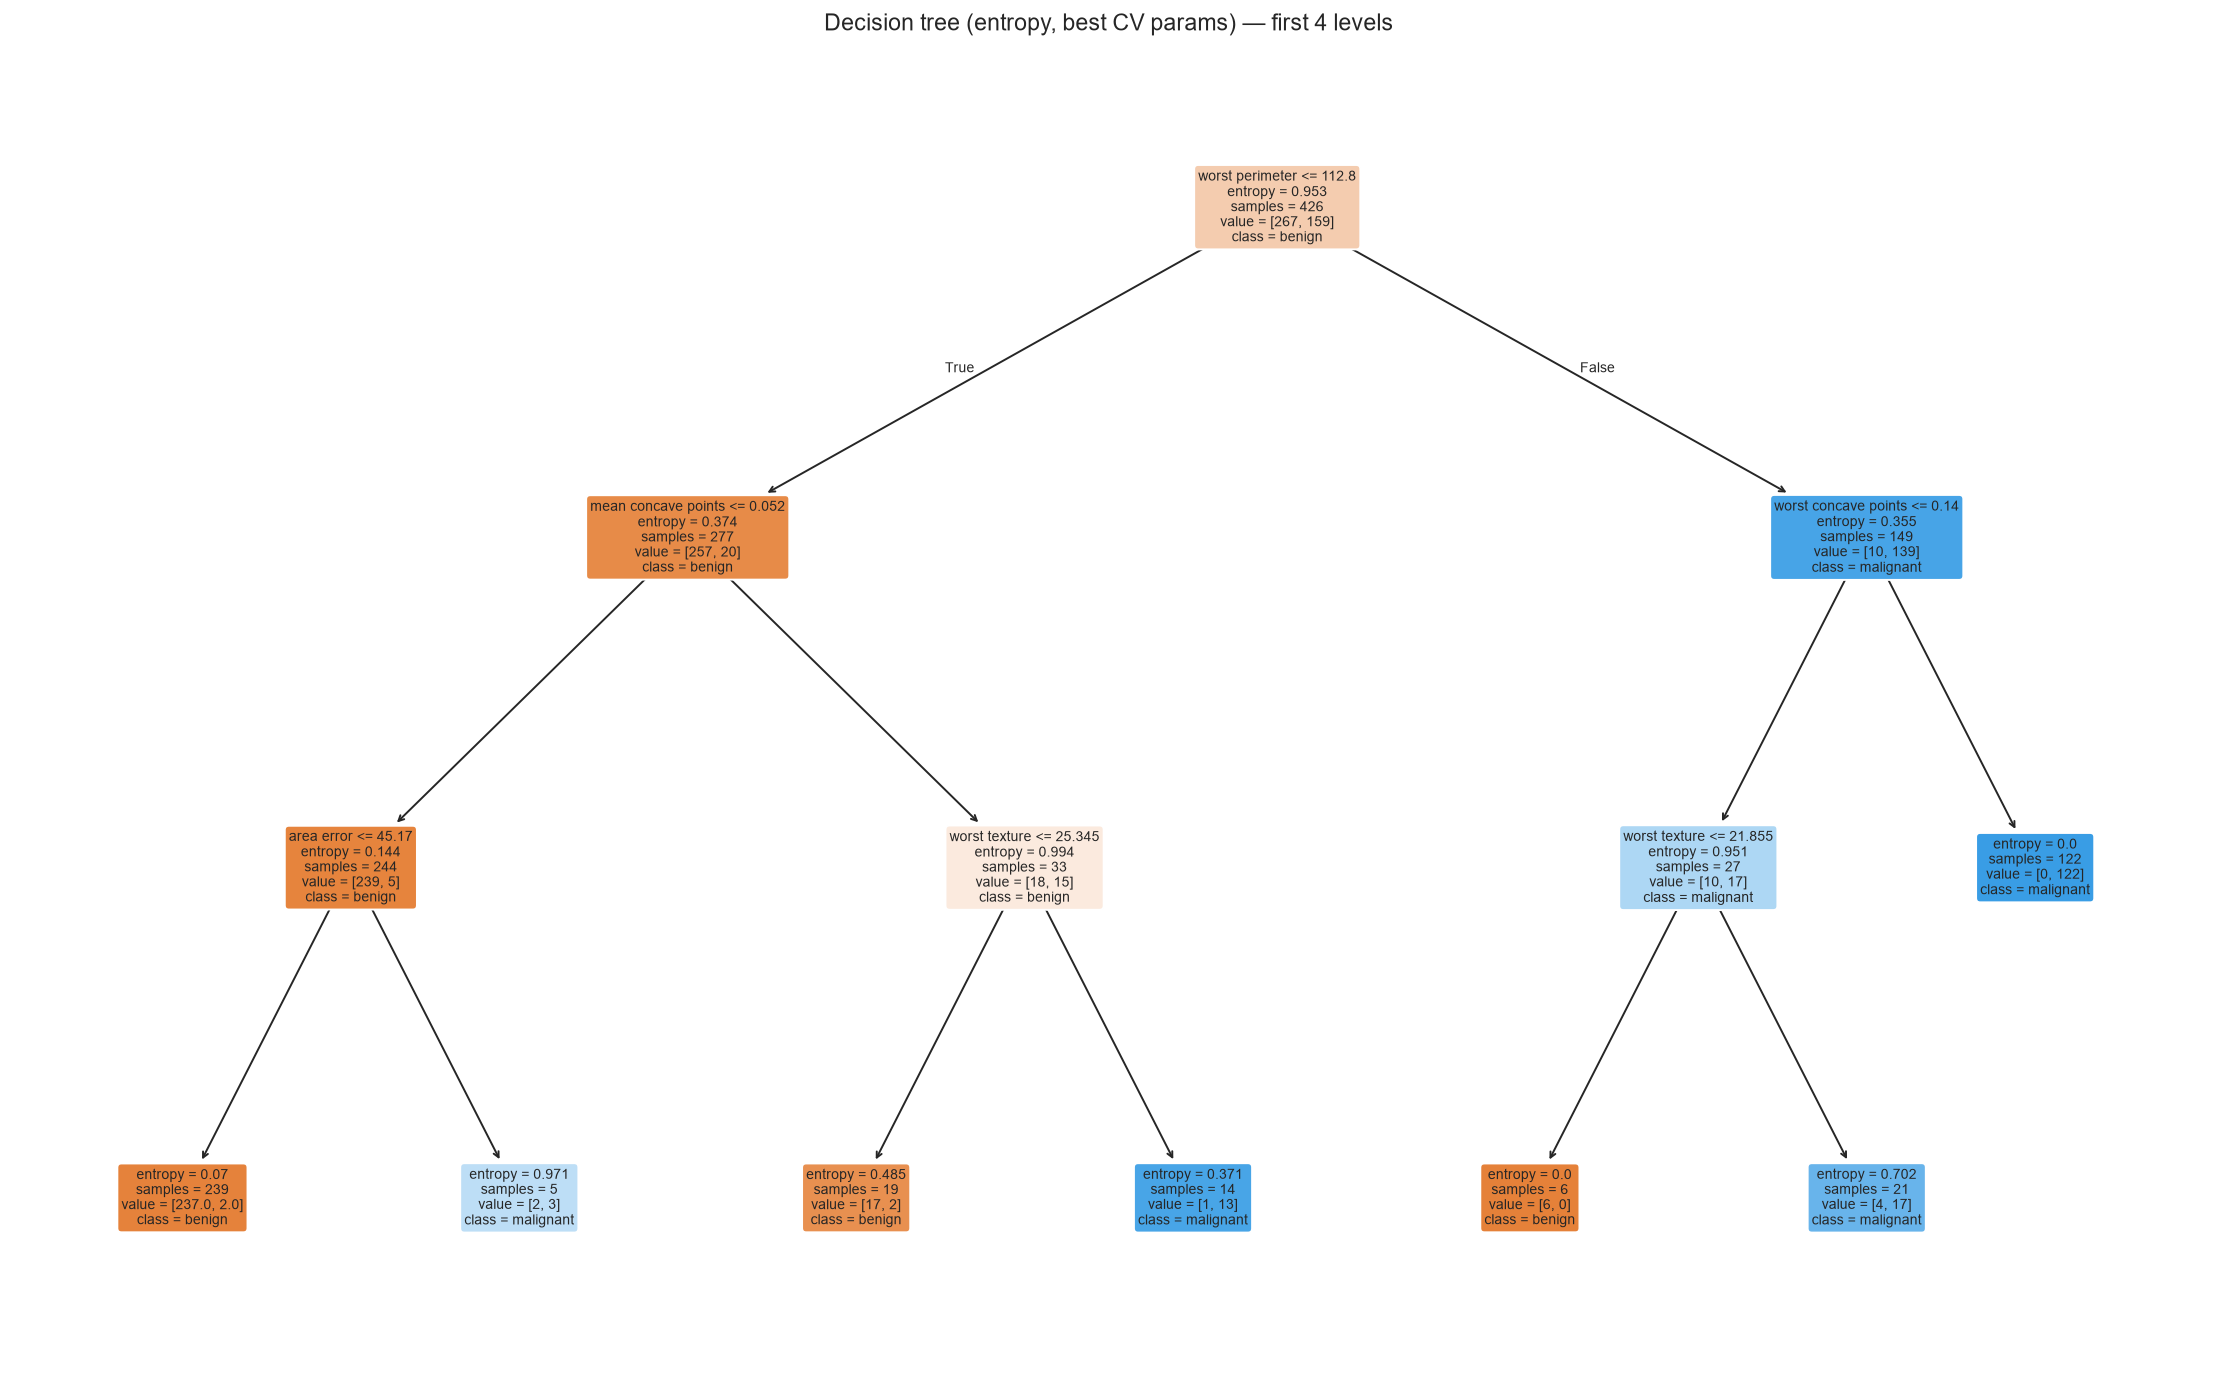

In [8]:
_banner("5.1 · plot_tree")

fig, ax = plt.subplots(figsize=(16, 10))
plot_tree(
    best,
    ax=ax,
    feature_names=feature_cols,          # why: readable splits, not X[17]
    class_names=["benign", "malignant"], # why: class 0 / 1 in that order
    filled=True,                         # why: colour by majority class / impurity
    rounded=True,
    fontsize=7,
)
ax.set_title("Decision tree (entropy, best CV params) — first 4 levels")
fig.tight_layout()
plt.show()


### 5.2 Train vs test accuracy versus `max_depth` (overfitting cartoon)

Deep trees **memorise** the training set. Test accuracy often peaks then **falls**.


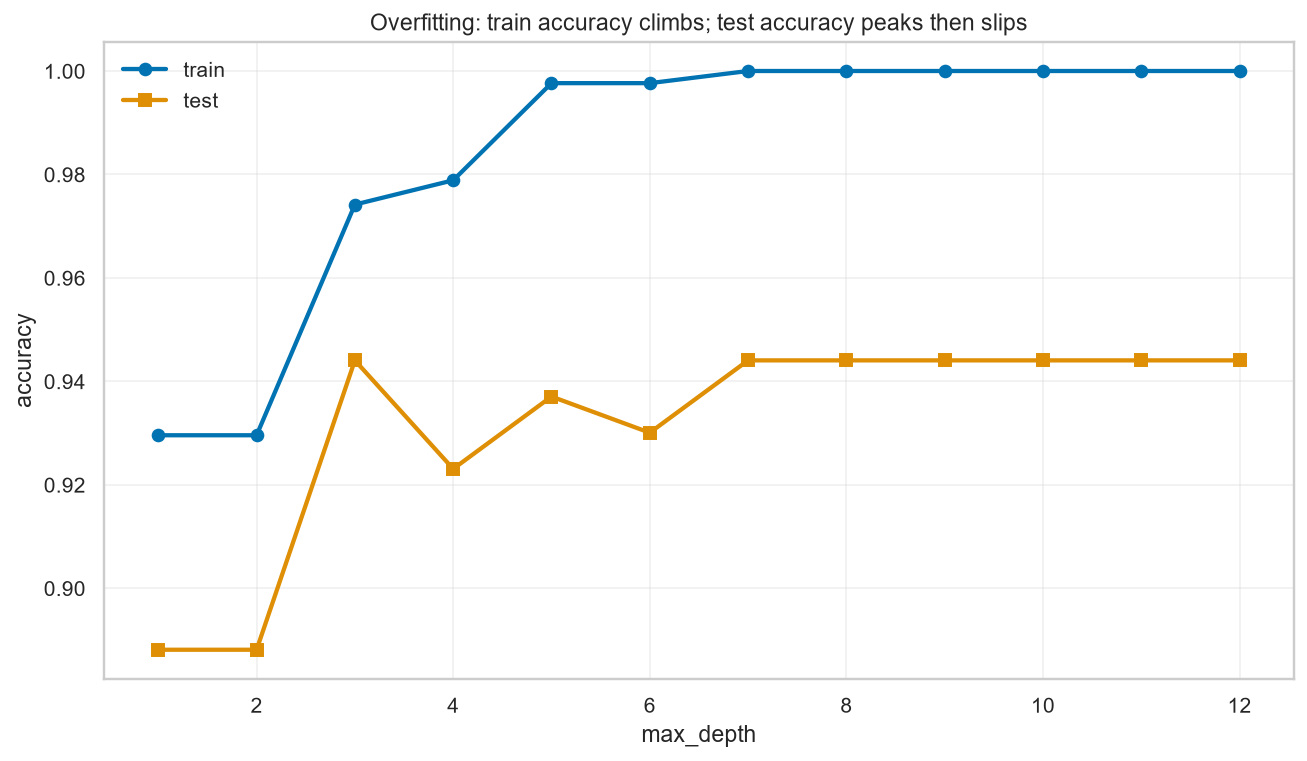

In [9]:
_banner("5.2 · Accuracy vs depth")

depths = list(range(1, 13))
acc_tr, acc_te = [], []
for d in depths:
    clf = DecisionTreeClassifier(
        criterion="entropy",  # why: same impurity as the grid-search model
        max_depth=d,          # why: the only knob we sweep in this plot
        random_state=SEED,
    )
    clf.fit(X_train, y_train)
    acc_tr.append(accuracy_score(y_train, clf.predict(X_train)))
    acc_te.append(accuracy_score(y_test, clf.predict(X_test)))

fig, ax = plt.subplots(figsize=(9.5, 5.6))
ax.plot(depths, acc_tr, marker="o", lw=2.2, label="train")
ax.plot(depths, acc_te, marker="s", lw=2.2, label="test")
ax.set_xlabel("max_depth")
ax.set_ylabel("accuracy")
ax.set_title("Overfitting: train accuracy climbs; test accuracy peaks then slips")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


### 5.3 Confusion matrix + ROC–AUC (test set)

ROC plots **true-positive rate** vs **false-positive rate** as the probability threshold moves. AUC $=1$ is perfect ranking; $0.5$ is a coin flip.


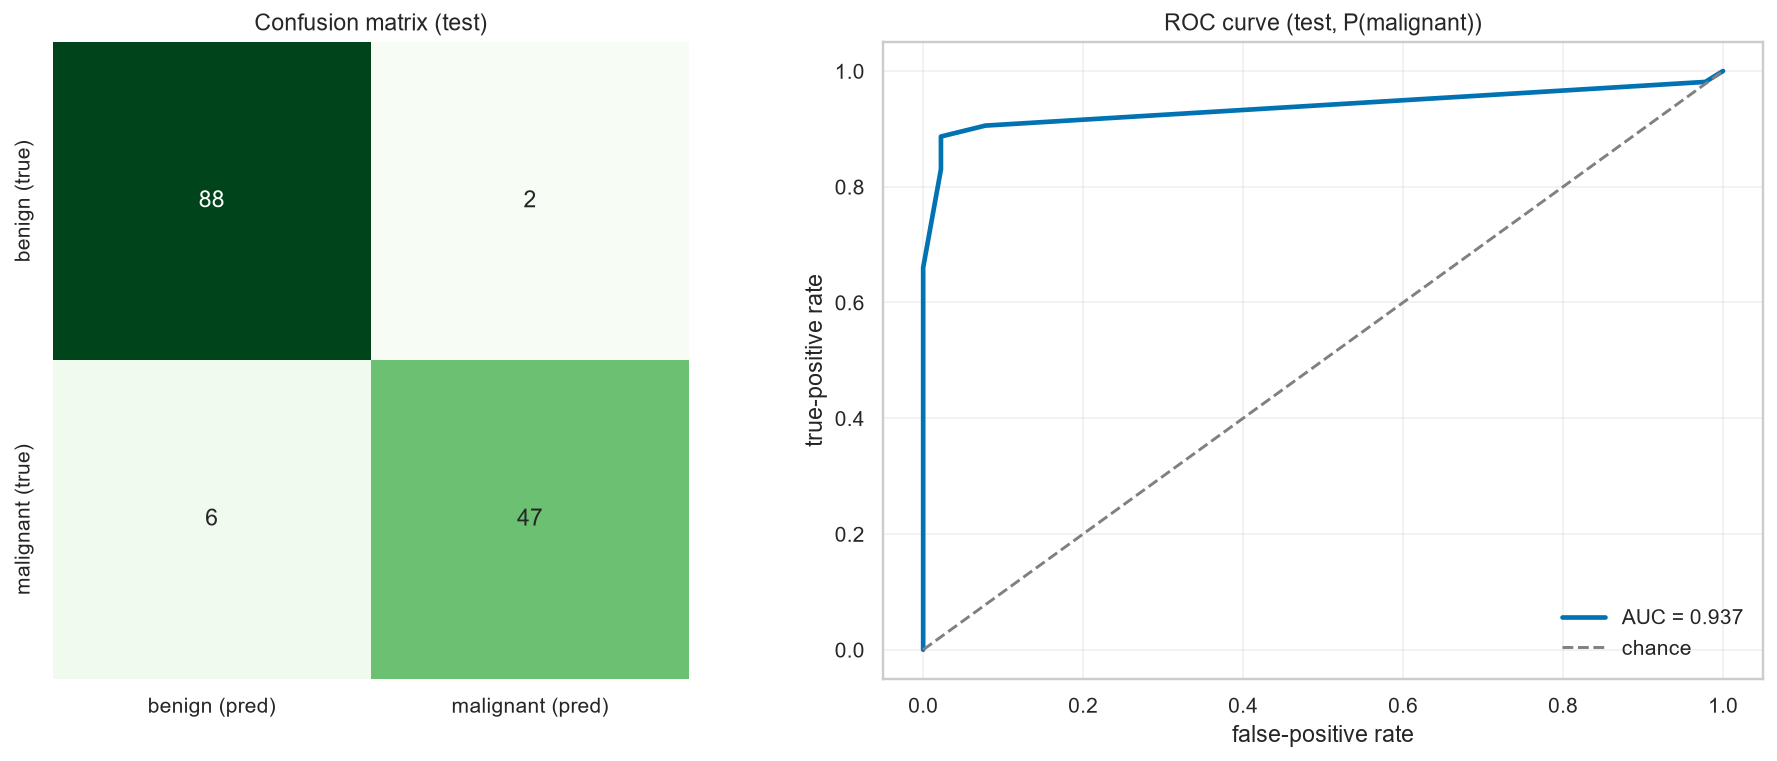

Test ROC-AUC = 0.9374


In [10]:
_banner("5.3 · Confusion matrix and ROC")

cm = confusion_matrix(y_test, yhat_te)
fpr, tpr, _ = roc_curve(y_test, proba_te)  # why: ranking quality, not a single 0.5 threshold
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6))
sns.heatmap(
    cm,
    ax=axes[0],
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["benign (pred)", "malignant (pred)"],
    yticklabels=["benign (true)", "malignant (true)"],
    square=True,
    cbar=False,
)
axes[0].set_title("Confusion matrix (test)")

axes[1].plot(fpr, tpr, lw=2.4, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], ls="--", c="0.5", label="chance")
axes[1].set_xlabel("false-positive rate")
axes[1].set_ylabel("true-positive rate")
axes[1].set_title("ROC curve (test, P(malignant))")
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()
print(f"Test ROC-AUC = {roc_auc:.4f}")


## 6. Viva-voce (indicative Q&A)

**Q1. Write Shannon entropy for a binary node.**  
**A.** $H=-p\log_2 p-(1-p)\log_2(1-p)$, with $0\log 0:=0$. For Play Tennis, $p=9/14$ gives $H(S)\approx 0.940$.

**Q2. Define information gain.**  
**A.** $\mathrm{IG}(S,A)=H(S)-\sum_v \frac{|S_v|}{|S|}H(S_v)$. ID3 maximises IG.

**Q3. Why is Outlook the root?**  
**A.** It has the largest IG among Outlook, Temperature, Humidity, Wind (overcast child is already pure).

**Q4. Why not always pick the attribute with the most values?**  
**A.** Raw IG is biased toward many-valued attributes. C4.5 uses **gain ratio**. Tennis attributes are all small-cardinality, so ID3 is safe.

**Q5. When does ID3 stop?**  
**A.** Pure labels, no attributes left, IG $\le 0$, or an optional size/depth cap.

**Q6. Entropy vs Gini?**  
**A.** Both are impurity scores. Gini $=1-\sum p_k^2$ (CART). sklearn `criterion='entropy'` is ID3-like impurity with CART binary splits on numbers.

**Q7. Why `stratify=y` in `train_test_split`?**  
**A.** Keeps the malignant/benign ratio in both splits so accuracy is not an artefact of a lucky test bag.

**Q8. What does `max_depth` control?**  
**A.** How many questions the tree may ask. Too large → overfit (train acc $\to 1$, test acc falls).

**Q9. What does `min_samples_split` do?**  
**A.** Refuses to split a node with fewer than that many rows — a simple pre-prune.

**Q10. Read a confusion matrix.**  
**A.** Rows = truth, columns = prediction (as labelled). False negatives = missed malignancies (costly in screening).

**Q11. What is ROC–AUC?**  
**A.** Area under TPR vs FPR as the threshold varies. It scores ranking of $P(\text{malignant})$, not one cut-off.

**Q12. Scratch ID3 vs sklearn tree on cancer — why different trees?**  
**A.** Tennis ID3 is **multiway categorical**. sklearn uses **binary threshold cuts** on continuous assays. Same entropy idea, different split grammar.


## 7. Conclusion

This practical locked in **ID3 as entropy reduction**:

1. **CONFIG** — `DATA_PATH`, `FEATURE_COLUMNS`, `TARGET_COLUMN`, `DROP_COLUMNS`, `PLAY_TENNIS_PATH`.
2. **Hand table** — $H(S)\approx 0.940$, child entropies, IG ranking with **Outlook** at the root.
3. **From-scratch ID3** — recursive, ASCII print, perfect train fit on 14 noiseless rows.
4. **sklearn** — entropy tree, CV search over depth / `min_samples_split`, hold-out metrics.
5. **Figures** — `plot_tree`, train/test vs depth, confusion matrix + ROC.

**Next practical:** $k$-NN — still without touching `extra/`.

### Submission checklist

- [ ] Re-run all cells on `ml-lab-kernel`
- [ ] Paste $H(S)$ and the four IG values in the lab record
- [ ] Record best `max_depth`, test accuracy, and ROC–AUC
